In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features: sepal length, sepal width, petal length, petal width
y = iris.target  # Target: species (0=setosa, 1=versicolor, 2=virginica)

# Create a DataFrame for better visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("📊 Dataset Shape:", df.shape)
print("\n🔍 First 5 rows:")
print(df.head())

print("\n📈 Dataset Info:")
print(df.info())

print("\n📊 Basic Statistics:")
print(df.describe())

print("\n🎯 Target Distribution:")
print(df['species_name'].value_counts())

📊 Dataset Shape: (150, 6)

🔍 First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

📈 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal le

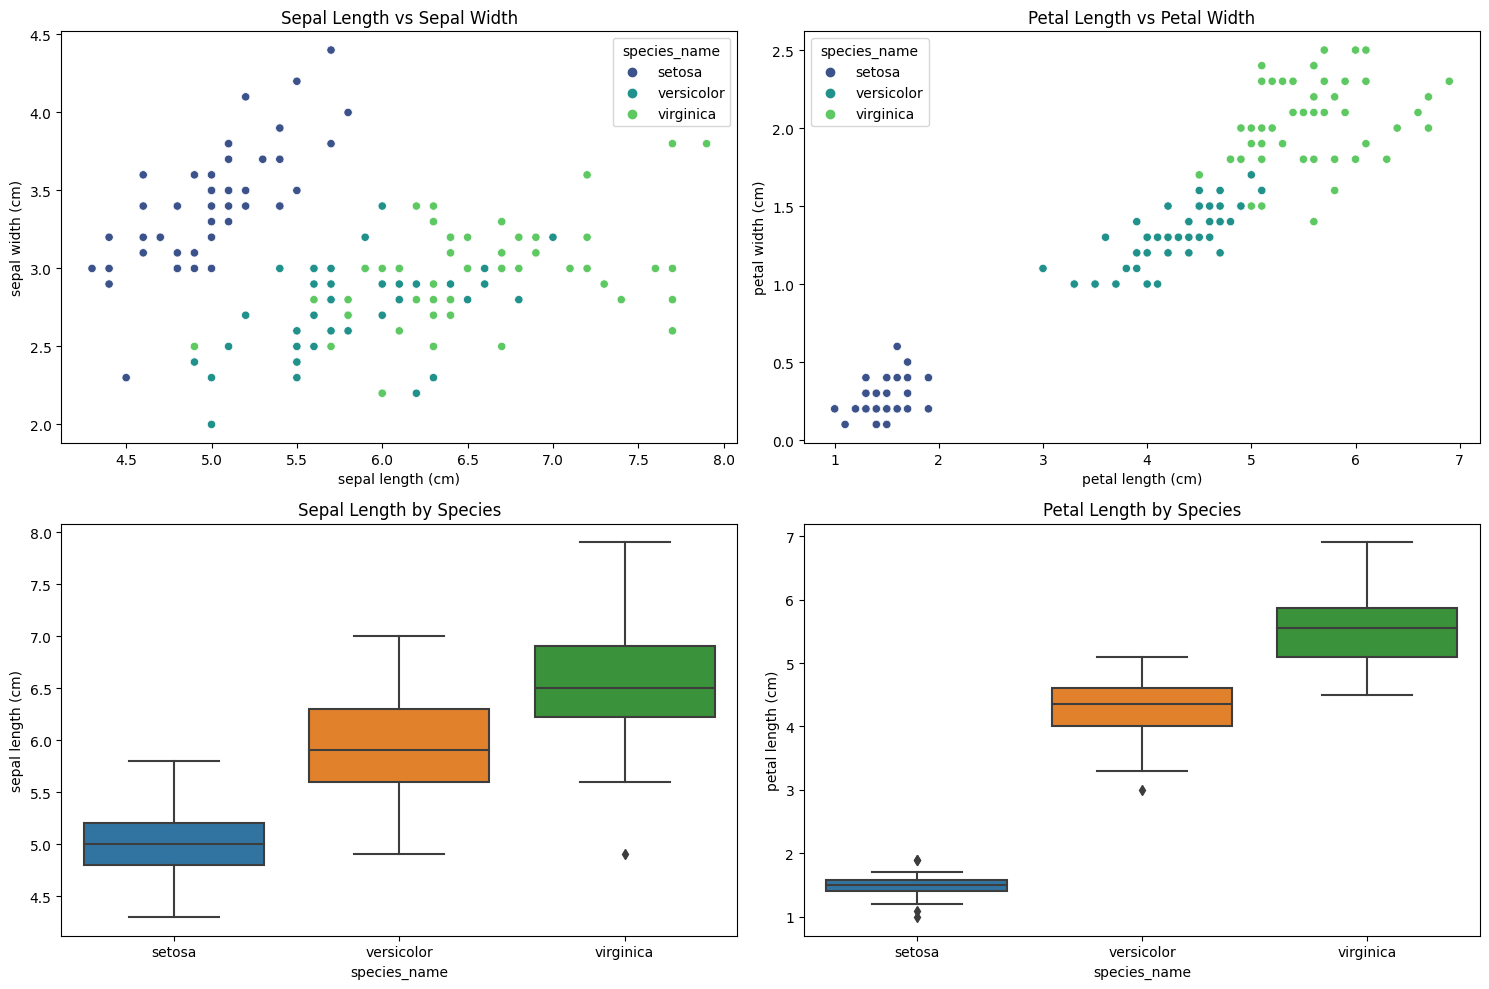

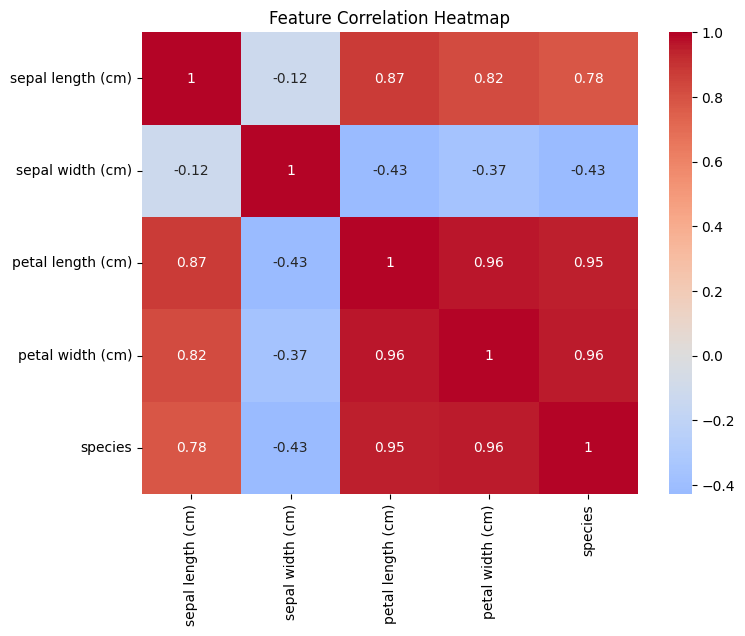

In [3]:
# Set up the plotting style
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Sepal length vs Sepal width
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)', 
                hue='species_name', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Sepal Length vs Sepal Width')

# Plot 2: Petal length vs Petal width
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', 
                hue='species_name', ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Petal Length vs Petal Width')

# Plot 3: Feature distributions by species
sns.boxplot(data=df, x='species_name', y='sepal length (cm)', ax=axes[1,0])
axes[1,0].set_title('Sepal Length by Species')

sns.boxplot(data=df, x='species_name', y='petal length (cm)', ax=axes[1,1])
axes[1,1].set_title('Petal Length by Species')

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [4]:
# Prepare features and target
X = df.drop(['species', 'species_name'], axis=1)
y = df['species']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("📊 Data Split Summary:")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

📊 Data Split Summary:
Training set size: 120 samples
Testing set size: 30 samples
Number of features: 4


In [5]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    # Train the model
    if name in ['Logistic Regression', 'Support Vecotr Machine']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"✅ {name} - Accuracy: {accuracy:.4f}")

# Compare model performance
print("\n🏆 Model Comparison:")
for name, accuracy in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {accuracy:.4f}")

✅ Logistic Regression - Accuracy: 0.9333
✅ K-Nearest Neighbors - Accuracy: 1.0000
✅ Support Vector Machine - Accuracy: 0.9667
✅ Decision Tree - Accuracy: 0.9333
✅ Random Forest - Accuracy: 0.9000

🏆 Model Comparison:
K-Nearest Neighbors: 1.0000
Support Vector Machine: 0.9667
Logistic Regression: 0.9333
Decision Tree: 0.9333
Random Forest: 0.9000



🎯 Best Model: K-Nearest Neighbors

📋 Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



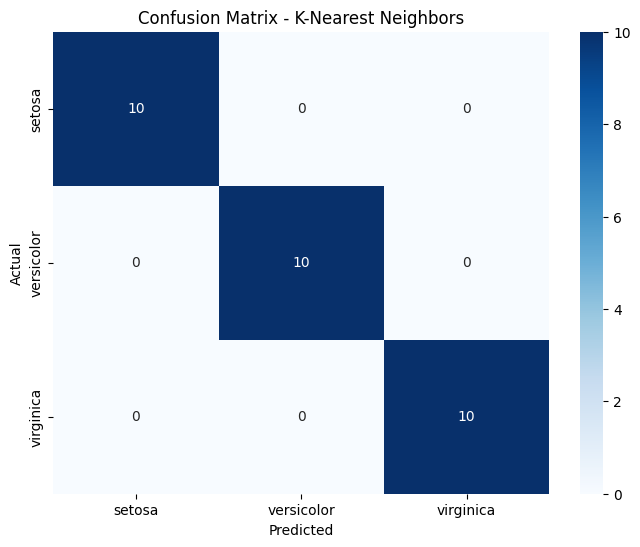

In [6]:
# Let's use the best performing model for detailed analysis
best_model_name = max(results, key=results.get)
print(f"\n🎯 Best Model: {best_model_name}")

if best_model_name in ['Logistic Regression', 'SVM']:
    best_model = models[best_model_name]
    best_model.fit(X_train_scaled, y_train)
    y_pred = best_model.predict(X_test_scaled)
else:
    best_model = models[best_model_name]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

# Detailed evaluation
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [7]:
# Function to make predictions on new flower measurements
def predict_iris_species(sepal_length, sepal_width, petal_length, petal_width, model, scaler=None):
    """
    Predict the species of an iris flower based on its measurements
    """
    # Create input array
    input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    
    # Scale if needed
    if scaler is not None:
        input_data = scaler.transform(input_data)
    
    # Make prediction
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0] if hasattr(model, 'predict_proba') else [1, 0, 0]
    
    species_name = iris.target_names[prediction]
    
    print(f"🌺 Prediction: {species_name}")
    print(f"📊 Confidence: {max(probability):.2%}")
    print(f"🔢 Probabilities:")
    for i, prob in enumerate(probability):
        print(f"   {iris.target_names[i]}: {prob:.2%}")
    
    return species_name

# Test with some example measurements
print("🧪 Testing with example flowers:")
print("\nExample 1 - Likely Setosa:")
predict_iris_species(5.1, 3.5, 1.4, 0.2, best_model, scaler if best_model_name in ['Logistic Regression', 'SVM'] else None)

print("\nExample 2 - Likely Versicolor:")
predict_iris_species(6.0, 2.7, 4.2, 1.3, best_model, scaler if best_model_name in ['Logistic Regression', 'SVM'] else None)

print("\nExample 3 - Likely Virginica:")
predict_iris_species(7.2, 3.0, 5.8, 2.1, best_model, scaler if best_model_name in ['Logistic Regression', 'SVM'] else None)

🧪 Testing with example flowers:

Example 1 - Likely Setosa:
🌺 Prediction: setosa
📊 Confidence: 100.00%
🔢 Probabilities:
   setosa: 100.00%
   versicolor: 0.00%
   virginica: 0.00%

Example 2 - Likely Versicolor:
🌺 Prediction: versicolor
📊 Confidence: 100.00%
🔢 Probabilities:
   setosa: 0.00%
   versicolor: 100.00%
   virginica: 0.00%

Example 3 - Likely Virginica:
🌺 Prediction: virginica
📊 Confidence: 100.00%
🔢 Probabilities:
   setosa: 0.00%
   versicolor: 0.00%
   virginica: 100.00%


'virginica'

🔍 Calculating Permutation Importance for KNN...

📊 Permutation Feature Importance:
             feature  importance_mean  importance_std
2  petal length (cm)         0.611111        0.100493
3   petal width (cm)         0.171111        0.052163
0  sepal length (cm)         0.043333        0.019532
1   sepal width (cm)         0.016667        0.018758


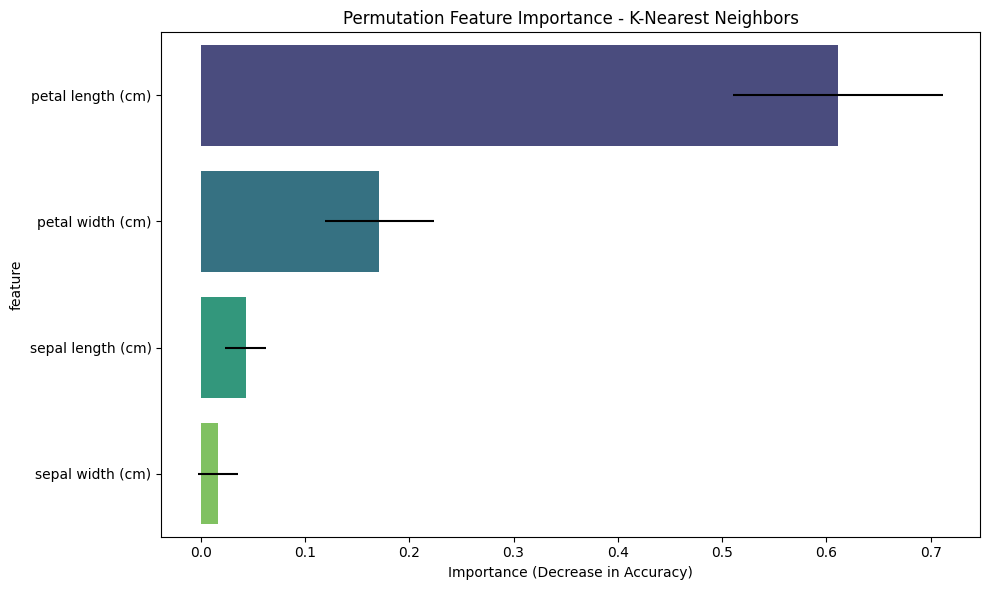

In [8]:
# Step 8: Feature Importance Analysis

# Method 1: Permutation Importance (Works for any model)

print("🔍 Calculating Permutation Importance for KNN...")

# Calculate permutation importance
perm_importance = permutation_importance(
    best_model, 
    X_test if best_model_name not in ['Logistic Regression', 'SVM'] else X_test_scaled, 
    y_test, 
    n_repeats=30, 
    random_state=42
)

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'feature': iris.feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\n📊 Permutation Feature Importance:")
print(feature_importance_df)

# Plot permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='importance_mean', y='feature', 
            palette='viridis', xerr=feature_importance_df['importance_std'])
plt.title(f'Permutation Feature Importance - {best_model_name}')
plt.xlabel('Importance (Decrease in Accuracy)')
plt.tight_layout()
plt.show()

In [9]:
# Save the model
model_artifacts = {
    'model': best_model,
    'scaler': scaler if best_model_name in ['Logistic Regression', 'SVM'] else None,
    'feature_names': iris.feature_names,
    'target_names': iris.target_names.tolist()
}

joblib.dump(model_artifacts, 'iris_classifier.pkl')
print("💾 Model artifacts saved as 'iris_classifier.pkl'")

print("\n🎉 Project Completed Successfully!")
print("📈 Final Accuracy: {:.2f}%".format(results[best_model_name] * 100))

💾 Model artifacts saved as 'iris_classifier.pkl'

🎉 Project Completed Successfully!
📈 Final Accuracy: 100.00%
